# RAGuesser — Walkthrough

This notebook walks through the **complete architecture** of a **theme-routed RAG agent** for the *Who Wants to Be a Millionaire* benchmark, running 14B-class models on a single Google Colab T4 GPU under a hard **30-second-per-question** time budget.

# Notebook Parts

1. **Hardware & time constraints** that shaped every design decision
2. **Theme-based routing architecture** — three strategies, one entry point
3. **Model loading** with 4-bit quantization (NF4) on a 16 GB T4
4. **Shared building blocks** — chunking, query cleaning, answer parsing
5. **Strategy 1 — Wikipedia RAG** for Entertainment, History, Science, Philosophy
6. **Strategy 2 — News via Guardian API** with date-window filtering
7. **Strategy 3 — Math with a streaming time budget** + refine-on-timeout
8. **Game loop & per-run metrics** computed in-notebook
9. **Experiment runner** — all six categories, model-swap minimization


## Part 1 — The Constraints

### Hardware
Inference runs on **Google Colab's free-tier T4**: 16 GB VRAM, fixed for the session. No ability to scale up, no second GPU, and the runtime disconnects after idle periods (so model weights have to be re-fetched).

### The wall — 30 seconds per question
The Millionaire server enforces a strict **30-second hard timeout per question**. Any pipeline that takes longer scores zero on that question regardless of correctness, and ends the run for that competition.

### Constraints summary

| Limitation | Direct consequence on the design |
|---|---|
| **16 GB VRAM** | Cannot hold both models simultaneously at fp16. Forces 4-bit NF4 quantization, and even then only **one model loaded at a time**. Must swap when switching to Math which introduces lots of time in-between categories. |
| **30s hard timeout** | Math reasoning cannot run unbounded. Must use a **wall-clock watchdog** with a graceful refine fallback. RAG retrieval is parallelized to reduce search time. |
| **CPU-only reranker** | Cross-encoder runs on CPU (no spare VRAM). Reduce its workload to ≤10 chunks per question via a fast BM25 prefilter. |

### Why not a smaller model?
Tested earlier with 7B-class models: math accuracy collapsed and RAG branches misread retrieved evidence consistently. 14B at q4 is the sweet spot as it fits comfortably on T4 (~9 GB per model). The idea was to use the biggest model possible as the "only" two constraints were Google Colab's hardware and the 30 second per-question timeout as previously said.


In [ ]:
#INITIALIZE THESE VALUES
mail = ""
user_name = ""
GUARDIAN_KEY = ""

from google.colab import drive
import os
import sys
import threading
from datetime import datetime, timedelta

drive.mount('/content/gdrive/')

# Define the path to the directory containing your package
package_parent_dir = '/content/gdrive/MyDrive/Colab Notebooks'

# Append to sys.path if it is not already present
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

# Verify the path was added
print(sys.path)

#Import client
from millionaire_client import MillionaireClient, AuthenticationError

#Get password
from google.colab import userdata
pwd = userdata.get('poli-millionaire')

#Login
API_URL = "http://131.175.15.22:51111/"
username = user_name
password = pwd
client = MillionaireClient(API_URL)
try:
    user = client.login(username, password)
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/gdrive/MyDrive/Colab Notebooks']

Welcome, Pastasciutta! (Role: student)


## Part 2 — The Architecture: Theme-Based Routing

The Millionaire client tells us the competition theme up front (`comp_id`), so the question is *already* classified. We exploit that by routing each question through a strategy tuned to its theme as seen from the figure in the next cell.

### Why route at all?
Earlier iterations used one generic prompt for every theme. Two problems surfaced:
1. **Math doesn't benefit from retrieval.** Wikipedia search wastes 5–10s on questions where the answer must be *computed*, not looked up.
2. **News is time-stamped.** The questions explicitly reference dated 2026 articles (`"According to the article published on 2026-05-18..."`). Wikipedia has none of those. We need a corpus that publishes news, with date filtering.

The alternative (one giant prompt that tries to do everything) underperformed every category.

### The shared substrate
Even though the three branches behave differently at retrieval, they share:
- **Chunking** (`chunk_text`) — paragraph-then-sentence splits ≤250 words.
- **BM25 prefilter + cross-encoder rerank** — same code, fed different chunks.
- **`build_doc_prompt`** — the final document-grounded prompt to the LLM.
- **`final_answer_regex`** — cascading regex to parse `FINAL_ANSWER: X` (with fallbacks).

Only the retrieval frontend differs.


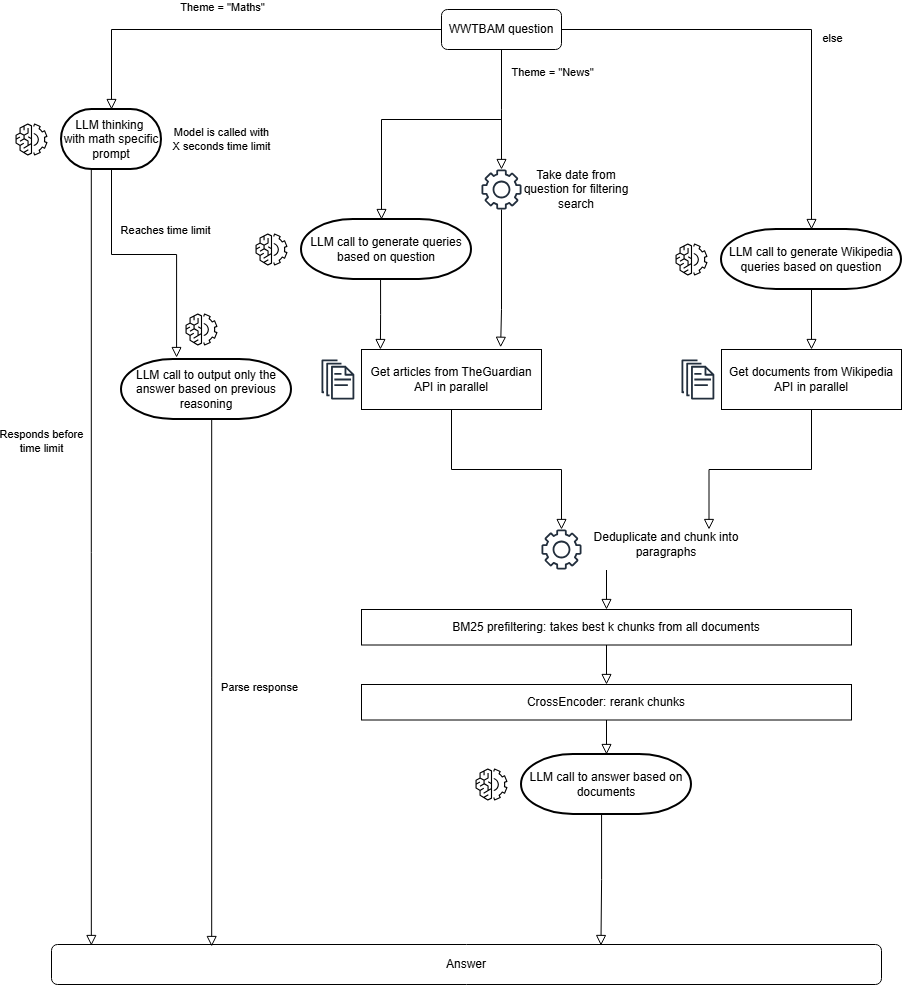

In [ ]:
from IPython.display import Image, display
display(Image('/content/gdrive/MyDrive/architecture.png'))

## Part 3 — Model Loading & Quantization

### Why two models?
- **`Qwen/Qwen2.5-14B-Instruct`** — general instruction-following model. Used for RAG branches and News (both follow the same "given documents, answer A/B/C/D" pattern).
- **`Qwen/Qwen3-8B`** — reasoning model. Better than Qwen2.5 on Maths because the chain-of-thought training transfers to step-by-step math.

### Why not one of each at the same time?
Loading both simultaneously would oversubscribe VRAM and either OOM or fall back to CPU offload (which is too slow for the 30s budget).

So the runner loads **one model**, runs all competitions that use it, then **swaps** to the other. This introduces lots of latency in-between categories but does not affect the actual performance of the pipeline.

### The loader
A small global state (`current_model`, `current_tokenizer`, `current_name`) tracks which model is currently in VRAM. `load_model(name)` is a no-op if the requested model is already loaded; otherwise it deletes the old one, runs `gc.collect()` + `torch.cuda.empty_cache()`, and instantiates the new one with the 4-bit `BitsAndBytesConfig`.


In [ ]:
!pip install -U transformers accelerate bitsandbytes
!pip install sentence-transformers
!pip install rank-bm25
from sentence_transformers import SentenceTransformer, util, CrossEncoder
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from concurrent.futures import ThreadPoolExecutor
from rank_bm25 import BM25Okapi
import torch
import re
import random
import time
import requests
import numpy as np
import gc
import pandas as pd

HEADERS = {
    "User-Agent": (
        "WhoWantsToBeAMillionaire-Bot/1.0 (research project;"
        f" {mail})"
    )
}

reranker = CrossEncoder("BAAI/bge-reranker-base",device="cuda")

def load_model(model_name):
    global current_model, current_tokenizer, current_name
    if current_name == model_name:
        return

    if current_model is not None:
        del current_model
        current_model = None
    if current_tokenizer is not None:
        del current_tokenizer
        current_tokenizer = None

    gc.collect()
    torch.cuda.empty_cache()

    free, total = torch.cuda.mem_get_info()
    print(f"Free VRAM: {free/1e9:.2f} GB / {total/1e9:.2f} GB")

    current_tokenizer = AutoTokenizer.from_pretrained(model_name)
    current_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quant_config,
        device_map="auto",
        torch_dtype=torch.float16
    )
    current_name = model_name
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)
current_model = None
current_tokenizer = None
current_name = None
rag_model = "Qwen/Qwen2.5-14B-Instruct"
#math_model = "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B"
math_model = "Qwen/Qwen3-8B"

config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

## Part 4 — Shared Building Blocks

These helper functions are used almost everywhere in all branches.

### `chunk_text` — paragraph-first, sentence-aware
Splits text by `\n\n` (paragraphs). If a paragraph is ≤250 words, keep it intact. If it's longer, split into sentences with `(?<=[.!?])\s+` and pack sentences into ≤250-word groups, never breaking mid-sentence. This preserves local coherence — the reranker sees self-contained passages instead of arbitrary cuts.

### `clean_query` — defensive sanitization
LLMs occasionally output Chinese characters, glued-together words, leading bullets, multi-line ramblings. `clean_query` strips quotes, takes the first line only, removes anything that isn't `[a-zA-Z0-9\s\-']`, collapses whitespace, and caps the length at 120 chars. This stops nonsense queries from polluting Wikipedia / Guardian search results.

### `bm25_prefilter` — cheap and discriminative
With ~50–200 chunks per question (3 queries × multiple articles × multiple paragraphs each), running a cross-encoder on all of them could blow the 30s budget. BM25 is keyword-based, fast on the full chunk pool, and shrinks the candidate set to 10 — enough signal for the reranker to do precise work.

### `rerank_chunks` — semantic precision on a small set
`BAAI/bge-reranker-base` cross-encoder. Scores each of the prefiltered chunks against `question + options` as a single concatenated query. We deduplicate by normalized chunk text (whitespace + lowercase) before truncating to top-5 — important because Wikipedia articles often have near-identical passages.

### `final_answer_regex` — cascading parser
The strict format is `FINAL_ANSWER: X`. But LLMs frequently violate it (markdown bold, "Final Answer: A", "the answer is C"). Four-tier cascade:

1. `FINAL_ANSWER: X` (tolerates `**FINAL_ANSWER**:`)
2. `Final Answer: X` / `Final answer X` (case-insensitive, markdown-tolerant)
3. `answer is X` / `answer is (X)`
4. Falls through to `False` (callers handle this with a random fallback)


In [ ]:
def chunk_text(text, max_words=250):
    paragraphs = text.split("\n\n")
    chunks = []
    for p in paragraphs:
        p = p.strip()
        if not p:
            continue
        words = p.split()
        if len(words) <= max_words:
            chunks.append(p)
            continue
        sentences = re.split(r'(?<=[.!?])\s+', p)
        current_chunk = []
        current_word_count = 0
        for sentence in sentences:
            sentence_words = sentence.split()
            sentence_word_count = len(sentence_words)
            if current_word_count + sentence_word_count > max_words and current_chunk:
                chunks.append(" ".join(current_chunk))
                current_chunk = sentence_words
                current_word_count = sentence_word_count
            else:
                current_chunk.extend(sentence_words)
                current_word_count += sentence_word_count
        if current_chunk:
            chunks.append(" ".join(current_chunk))
    return chunks


def clean_query(q):
    q = q.strip().replace('"', "")
    q = q.split("\n")[0]
    q = re.sub(r"[^a-zA-Z0-9\s\-']", " ", q)
    q = re.sub(r"\s+", " ", q).strip()
    return q[:120]

def rerank_chunks(question, options, chunks, top_k=3):
    start_time = time.time()
    query = question + " " + " ".join(options)
    pairs = [[query, chunk] for chunk in chunks]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(scores, chunks), key=lambda x: x[0], reverse=True)
    seen = set()
    final = []
    for score, chunk in ranked:
        norm = re.sub(r"\s+", " ", chunk.strip().lower())
        if norm not in seen:
            seen.add(norm)
            final.append(chunk)
        if len(final) == top_k:
            break
    print(f"Time to rerank documents {time.time() - start_time:.1f}")
    return final


def bm25_prefilter(question, options, chunks, top_k=10):
    start_time = time.time()
    query = f"{question} {' '.join(options)}"
    tokenized_query = query.lower().split()
    tokenized_chunks = [c.lower().split() for c in chunks]
    bm25 = BM25Okapi(tokenized_chunks)
    scores = bm25.get_scores(tokenized_query)
    ranked = sorted(zip(scores, chunks), key=lambda x: x[0], reverse=True)
    print(f"Time to bm25 prefilter documents {time.time() - start_time:.3f}")
    return [chunk for _, chunk in ranked[:top_k]]

def final_answer_regex(text: str):
    match = re.search(r"\*{0,2}FINAL_ANSWER\*{0,2}:\s*([ABCD])", text)
    if match:
        return match.group(1)
    match = re.search(r"[Ff]inal\s+[Aa]nswer\*{0,2}:?\*{0,2}\s*([ABCD])\b", text)
    if match:
        return match.group(1)
    match = re.search(r"[Aa]nswer\s+is\s+\(?([ABCD])\)?", text)
    if match:
        return match.group(1)
    return False


## Part 5 — Strategy 1: Wikipedia RAG

Used for **Entertainment**, **Ancient History & Politics**, **Science & Nature**, and **Philosophy & Psychology**.

### Pipeline
```
Question
   │
   ▼
┌──────────────────────────────┐
│ build_query_prompt + LLM      │  Qwen2.5-14B generates 3 search queries
└──────────────────────────────┘
   │
   ▼
┌──────────────────────────────┐
│ wikisearch_multi (parallel)   │  3× wikisearch_single → 2 titles each → 6 pages
└──────────────────────────────┘
   │
   ▼  Deduplicate by title
   │
   ▼
┌──────────────────────────────┐
│ chunk_text                    │  ≤250 words per chunk, paragraph-aware
└──────────────────────────────┘
   │
   ▼
┌──────────────────────────────┐
│ bm25_prefilter (top 10)       │  Fast keyword filter
└──────────────────────────────┘
   │
   ▼
┌──────────────────────────────┐
│ rerank_chunks (top 5)         │  Cross-encoder semantic rerank
└──────────────────────────────┘
   │
   ▼
┌──────────────────────────────┐
│ build_doc_prompt + LLM        │  Same Qwen2.5-14B picks A/B/C/D
└──────────────────────────────┘
```

### Design decisions

**No theme in the query prompt.** Earlier we passed the theme string into the system prompt (e.g., "this question is about Science"). Removing it improved query quality — the model stopped biasing toward theme-shaped queries and produced sharper named-entity queries instead. Extra tokens just confused it.

**Three queries per question, different angles.** A single query risks missing the right Wikipedia article. Three queries cover different facets: the named entity, the event, the broader concept. The system prompt explicitly asks for "different angles."

**2 titles per query, full text per article.** Wikipedia's `srlimit=2` returns the top two title matches; we then fetch the full `extract` for each via a second API call. Total: up to 6 articles per question.

**Title prefix `[Title]` on every chunk.** Cross-encoder needs context. A paragraph alone might be ambiguous; `[Steven Spielberg] During the 1980s, he...` is unambiguous and tells the reranker "this is article-level relevant."

**Negation handling in the doc prompt.** The system prompt explicitly addresses "NOT" / "except" / "false" questions because the model otherwise picks the most-supported option, ignoring the negation. This recovered several recurring failures (the Coppola/Godfather question was the diagnostic case).


In [ ]:
def build_query_prompt(question, options, theme):
    system_prompt = {
        "role": "system",
        "content": f"""You are a Wikipedia search assistant. Given a multiple choice question, output EXACTLY three Wikipedia search queries, one per line, nothing else.

Rules:
- Write short keyword phrases, not full sentences.
- Target Wikipedia article titles, named entities, historical events, or scientific concepts.
- Each query must be independently searchable and cover a different angle of the question.
- No filler words: avoid "what is", "explain", "who was", "describe".
- No numbering, no bullets, no extra text.

Example:
QUESTION: What element has atomic number 79?
A) Silver  B) Gold  C) Platinum  D) Copper
OUTPUT:
Gold chemical element
Atomic number periodic table
Noble metals chemistry""",
    }
    user_prompt = {
        "role": "user",
        "content": f"""#QUESTION: {question}

#OPTIONS:
A) {options[0]}
B) {options[1]}
C) {options[2]}
D) {options[3]}""",
    }
    return [system_prompt, user_prompt]


def build_doc_prompt(question, options, documents):
    system_prompt = {
        "role": "system",
        "content": """You are an expert quiz player. Use the provided documents as evidence.

Procedure:
1. Identify which document(s) contain the answer. If none do, rely on your own knowledge.
2. Quote (silently) the single sentence that decides the question.
3. Map that sentence to A, B, C, or D.

If two options are partially supported, pick the one that matches the question's exact wording (dates, names, units).

Output exactly one line:

FINAL_ANSWER: X

where X is A, B, C, or D.""",
    }
    formatted_docs = "\n\n".join(
        f"[Document {i+1}]\n{doc}" for i, doc in enumerate(documents)
    )
    user_prompt = {
        "role": "user",
        "content": f"""#QUESTION: {question}
#OPTIONS:
A) {options[0]}
B) {options[1]}
C) {options[2]}
D) {options[3]}

#REFERENCE DOCUMENTS:
{formatted_docs}""",
    }
    return [system_prompt, user_prompt]

def wikisearch_single(query):
    search_url = "https://en.wikipedia.org/w/api.php"
    search_params = {
        "action": "query",
        "list": "search",
        "srsearch": query,
        "format": "json",
        "srlimit": 2,
    }
    search_response = requests.get(search_url, params=search_params, headers=HEADERS)
    if not search_response.text or search_response.status_code != 200:
        return []
    titles = [r["title"] for r in search_response.json()["query"]["search"]]
    print(f"Titles found for query {query}: {titles}")
    pages = []
    for title in titles:
        extract_params = {
            "action": "query",
            "titles": title,
            "prop": "extracts",
            "explaintext": True,
            "format": "json",
        }
        extract_response = requests.get(search_url, params=extract_params, headers=HEADERS)
        if not extract_response.text or extract_response.status_code != 200:
            continue
        for page in extract_response.json()["query"]["pages"].values():
            if "extract" in page:
                pages.append((title, page["extract"]))
    return pages


def wikisearch_multi(queries, question, options):
    start_time = time.time()
    with ThreadPoolExecutor(max_workers=5) as executor:
        results = list(executor.map(wikisearch_single, queries))
    all_pages = [page for query_pages in results for page in query_pages]
    seen_titles = set()
    unique_pages = []
    for title, text in all_pages:
        if title not in seen_titles:
            seen_titles.add(title)
            unique_pages.append((title, text))
    all_chunks = []
    for title, text in unique_pages:
        for chunk in chunk_text(text):
            all_chunks.append(f"[{title}] {chunk}")
    if not all_chunks:
        return []
    print(f"Time to search the documents {time.time()-start_time:.1f}")
    prefiltered = bm25_prefilter(question, options, all_chunks, top_k=10)
    return rerank_chunks(question, options, prefiltered, top_k=5)

def call_model(prompt, temp=0.7, thinking=False, max_new_tokens=512):
    text = current_tokenizer.apply_chat_template(
        prompt,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = current_tokenizer(text, return_tensors="pt").to("cuda")
    input_length = inputs["input_ids"].shape[1]

    outputs = current_model.generate(
        **inputs,
        do_sample=(temp > 0),
        temperature=temp if temp > 0 else 1.0,
        max_new_tokens=max_new_tokens,
        pad_token_id=current_tokenizer.eos_token_id,
    )
    response = current_tokenizer.decode(
        outputs[0][input_length:], skip_special_tokens=True
    )
    return response

## Part 6 — Strategy 2: News via Guardian API

Used for **News**. The News questions reference *specific dated articles* (`"According to the article published on 2026-05-18..."`). Wikipedia has none of these. The benchmark uses **The Guardian** as the news corpus.

### Pipeline
```
Question (with date string "2026-05-XX")
   │
   ├──► parse_question_date  →  datetime(2026, 5, XX)
   │
   ▼
┌──────────────────────────────┐
│ build_news_query_prompt + LLM │  Same Qwen2.5-14B, but with a news-shaped
└──────────────────────────────┘  prompt: distinctive named entities first
   │
   ▼
┌──────────────────────────────┐
│ news_search_multi (parallel)  │  Guardian API: q=query, ±3-day date window,
└──────────────────────────────┘  show-fields=bodyText, top 5 per query
   │
   ▼  Deduplicate by webTitle
   │
   ▼
   ...then same chunk → BM25 → rerank → build_doc_prompt → LLM as RAG.
```

### Why the date window matters
Without `from-date` / `to-date`, Guardian's full-text relevance ranking returns long-tail noise — articles from 2020 about "Kenya transport" outrank the specific 2026 story. The ±3-day window (questions phrase "Monday" but the article may be published Tuesday) collapses the candidate set to a few hundred articles, and BM25 / rerank then pick the right one.

### Why the prompt is different from Wikipedia
The Wikipedia query prompt asks for *encyclopedic* keywords ("Gold chemical element"). News needs *named entities* — places, people, organizations, event names. The news-specific prompt explicitly tells the model: "Each query MUST include the most distinctive named entity," and asks for queries that all orbit the same entity (so the date filter has one anchor to lock onto, not three competing ones).

### API key
The Guardian Open Platform key is free, low-friction, and unrestricted for non-commercial use.


In [ ]:
def build_news_query_prompt(question, options):
    system = {
        "role": "system",
        "content": """You are a news search assistant. Given a multiple choice question about a published news article, output EXACTLY three news search queries, one per line.

- Each query MUST include the most distinctive named entity from the QUESTION
  (place, person, organization, event name).
- 2–4 words. Pick distinctive nouns over generic ones.
- All three queries should orbit the SAME entity, varying only the secondary term.
- Use ONLY terms from the QUESTION. NEVER use words that appear in the OPTIONS.

Example:
QUESTION: Where are white-tailed eagles set to be reintroduced?
OUTPUT:
White-tailed eagle reintroduction
White-tailed eagle UK
White-tailed eagle rewilding""",
    }
    user = {
        "role": "user",
        "content": f"""#QUESTION: {question}

#OPTIONS:
A) {options[0]}
B) {options[1]}
C) {options[2]}
D) {options[3]}"""
    }
    return [system, user]

def parse_question_date(text):
    m = re.search(r"(20\d{2})[-/](\d{1,2})[-/](\d{1,2})", text)
    if not m:
        return None
    try:
        return datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
    except ValueError:
        return None


def news_search_single(query, date_obj=None, window_days=3, page_size=5):
    if not GUARDIAN_KEY:
        print("NO KEY")
        return []
    params = {
        "q": query,
        "api-key": GUARDIAN_KEY,
        "show-fields": "bodyText",
        "page-size": page_size,
        "order-by": "relevance",
    }
    if date_obj:
        params["from-date"] = (date_obj - timedelta(days=window_days)).date().isoformat()
        params["to-date"]   = (date_obj + timedelta(days=window_days)).date().isoformat()
    try:
        url = "https://content.guardianapis.com/search"
        r = requests.get(url, params=params, headers=HEADERS, timeout=10)
        data = r.json()
        results = data.get("response", {}).get("results", [])
        kept = [(it["webTitle"], it["fields"].get("bodyText", ""))
                for it in results
                if it.get("fields", {}).get("bodyText")]
        return kept
    except Exception as e:
        print(f"Guardian fetch failed: {e}")
        return []


def news_search_multi(queries, question, options, date_obj=None):
    start = time.time()
    with ThreadPoolExecutor(max_workers=5) as ex:
        results = list(ex.map(lambda q: news_search_single(q, date_obj), queries))
    seen_titles, unique_pages = set(), []
    for pages in results:
        for title, text in pages:
            if title not in seen_titles:
                seen_titles.add(title)
                unique_pages.append((title, text))
    all_chunks = []
    for title, text in unique_pages:
        for chunk in chunk_text(text):
            all_chunks.append(f"[{title}] {chunk}")
    if not all_chunks:
        return []
    print(f"Time to search news: {time.time()-start:.1f}")
    prefiltered = bm25_prefilter(question, options, all_chunks, top_k=10)
    return rerank_chunks(question, options, prefiltered, top_k=5)

## Part 7 — Strategy 3: Math with a Streaming Time Budget

Used for **Maths**. Math is the category where every other strategy fails:
- **Retrieval doesn't help.** The answers are computed, not looked up. Wikipedia/Guardian RAG just wastes time.
- **Reasoning *does* help.** The model's `<think>` chain-of-thought is what makes it competitive on these problems.
- **But thinking is unbounded.** Once you enable thinking, the model can spend 60+ seconds on a single problem.

### The journey

**Attempt 1: `think=False`.** Disable thinking, get a fast answer. The model becomes essentially a worse Qwen2.5 with math accuracy ~25% (no better than guessing).

**Attempt 2: `think=True` with a token budget (`num_predict=N`).** Hits an N-token wall mid-thinking, never produces `FINAL_ANSWER:`. It's hard to put constraints inside the thinking part of the model, as it is "free" by default.

**Attempt 3: prompt the model to emit periodic `CURRENT_BEST: X` checkpoints, parse the latest one if time runs out.** The model **doesn't comply**, ignoring the checkpoint instruction and just thinks. Abandoned.

**Attempt 4: Multi-agent consensus.** A multi-agent consensus did not seem to work. As previously said, the main factor for accuracy is model size and the thinking benefit.

**Attempt 5 (current): wall-clock watchdog + refine call on partial trace.** Works.

Providing the model with tools like a calculator may improve accuracy, but introduces latency. Our experiments also showed that the model, given its size, makes most of its errors as reasoning errors, and not as math calculation errors.

### The current design
```
                              start
                                │
                                ▼
                ┌──────────────────────────────────┐
                │  LLM with think=True, generate()   │
                │  + TimeoutStoppingCriteria(25s)  │
                └──────────────────────────────────┘
                                │
                  ┌─────────────┴──────────────┐
                  ▼                            ▼
        ┌────────────────────┐        ┌────────────────────┐
        │  FINAL_ANSWER: X   │        │  Hit 25s deadline  │
        │  parsed from output│        │  (partial trace)   │
        └────────────────────┘        └────────────────────┘
                  │                            │
                  ▼                            ▼
              return X            ┌────────────────────────┐
                                  │ Refine call:           │
                                  │ - feed partial trace   │
                                  │ - think=False          │
                                  │ - max_new_tokens=20    │
                                  │ - "output ONLY:        │
                                  │   FINAL_ANSWER: X"     │
                                  └────────────────────────┘
                                              │
                                ┌─────────────┴────────────┐
                                ▼                          ▼
                        FINAL_ANSWER: X            Still nothing
                                │                          │
                                ▼                          ▼
                            return X         return random.choice(ABCD)
```

### Key implementation points

**`TimeoutStoppingCriteria`.** A subclass of HuggingFace's `StoppingCriteria` that returns `True` (= stop generating) when `time.time() > deadline`. Plugged into `generate(stopping_criteria=...)`, this gives a clean interrupt without thread juggling. The time budget also should leave some margin for the refine call plus network latency to the game server (2-3 seconds).

**`max_new_tokens=8192`.** Large enough that the model can think freely until the deadline; the stopping criteria cuts it off, not the token budget.

**Refine call: `do_sample=False, max_new_tokens=20`.** Strictly deterministic, no thinking, no room to wander. The reasoning context is already in the conversation; we just want the answer letter.

**Low temperature: ** A temperature of 0.1 has been empirically tested to be the best value for accuracy. It turns the LLM into a deterministic machine as much as possible while still having some wiggle room.

### What this buys
Math used to lose entire games to timeouts. With the watchdog + refine, the model commits to *something* every time. Even when the partial trace was inconclusive, the refine call often picks the option the model was leaning toward.



In [ ]:
def build_math_prompt(question, options):
    system = {
        "role": "system",
        "content": """You are solving timed multiple-choice math and statistics problems.

Strategy — pick whichever resolves the question fastest:
1. SUBSTITUTION: plug each option into the equation/condition and check which satisfies it.
2. ELIMINATION: rule out options that fail a quick check (sign, magnitude, units, parity, bounds).
3. DIRECT: solve and match.

Rules:
- Pick ONE strategy and execute. Do not re-derive what you've already computed.
- One sanity check is fine; repeated verification wastes time.
- If torn between two options after checking, commit to the one with the stronger constraint match.
- Definitions and theorem statements must be matched exactly — do not paraphrase.

Output exactly one line at the end:

FINAL_ANSWER: X

where X is A, B, C, or D.""",
    }
    user = {
        "role": "user",
        "content": f"""Question:
{question}

Options:
A) {options[0]}
B) {options[1]}
C) {options[2]}
D) {options[3]}""",
    }
    return [system, user]

from transformers import StoppingCriteria, StoppingCriteriaList

class TimeoutStoppingCriteria(StoppingCriteria):
    def __init__(self, deadline):
        self.deadline = deadline
    def __call__(self, input_ids, scores, **kwargs):
        return time.time() > self.deadline


def call_math_with_budget(prompt, hard_budget=25):
    text = current_tokenizer.apply_chat_template(
        prompt, tokenize=False, add_generation_prompt=True
    )
    inputs = current_tokenizer(text, return_tensors="pt").to("cuda")
    input_length = inputs["input_ids"].shape[1]

    deadline = time.time() + hard_budget
    stopping = StoppingCriteriaList([TimeoutStoppingCriteria(deadline)])

    try:
        outputs = current_model.generate(
            **inputs,
            max_new_tokens=8192,
            do_sample=True,
            temperature=0.1,
            stopping_criteria=stopping,
            pad_token_id=current_tokenizer.eos_token_id,
        )
        content = current_tokenizer.decode(
            outputs[0][input_length:], skip_special_tokens=True
        )
    except Exception as e:
        print(f"Math generation failed: {e}")
        content = ""

    print(f"Math model content: {content[-1500:]}")

    letter = final_answer_regex(content)
    if letter:
        return letter

    refine_prompt = prompt + [
        {"role": "assistant", "content": content[-3000:]},
        {"role": "user", "content": "Based on the reasoning above, output ONLY: FINAL_ANSWER: X"},
    ]
    try:
        refine_text = current_tokenizer.apply_chat_template(
            refine_prompt, tokenize=False, add_generation_prompt=True
        )
        refine_inputs = current_tokenizer(refine_text, return_tensors="pt").to("cuda")
        refine_in_len = refine_inputs["input_ids"].shape[1]
        refine_out = current_model.generate(
            **refine_inputs,
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=current_tokenizer.eos_token_id,
        )
        refine_resp = current_tokenizer.decode(
            refine_out[0][refine_in_len:], skip_special_tokens=True
        )
        letter = final_answer_regex(refine_resp)
        if letter:
            return letter
    except Exception as e:
        print(f"Refine call failed: {e}")

    return random.choice(['A', 'B', 'C', 'D'])

## Part 8 — The Game Loop & Per-Run Metrics

The game loop wraps `infer_answer` with per-question metric tracking, then aggregates into per-run summaries.

### What gets measured per question
| Metric | What it captures |
|---|---|
| `answer_time` | Total wall-clock from question shown to answer submitted. Includes everything: search, reasoning, network. |
| `search_time` | Time spent in retrieval (Wikipedia / Guardian + BM25 + rerank). Zero for math. |
| `reasoning_time` | Time the LLM spent generating the final answer (or, for math, the full streamed generation + refine). |

### What gets aggregated per run (one game = one run)
- `accuracy_per_run` = correct answers / questions attempted.
- `level_reached` = highest level reached before game-over.
- `game_won` = `num_correct >= max_levels` (true if you completed the ladder).
- `questions_answered`, `questions_correct` — kept separately so the runner can compute win rates and per-game stats post-hoc.

### Why per-question accuracy is misleading on its own
Millionaire is an **early-terminating** game. If you fail at level 1, that's one wrong answer counted once. If you cruise to level 14 and miss the last, that's 13 correct + 1 wrong. Both contribute to "mean accuracy," but they're wildly different outcomes. We deliberately track both raw counts and `game_won` so the post-hoc analysis can distinguish "consistently fails early" from "fails at the boss."


In [ ]:
# ==============================================================================
# CORE GUESSER — three branches (Maths / News / RAG)
# Comp ID mapping:
#   0 = Entertainment, 1 = Ancient History & Politics, 2 = Science & Nature,
#   3 = Maths,         4 = Philosophy & Psychology,    5 = News
# ==============================================================================

THEME_BY_COMP = {
    0: "Entertainment",
    1: "Ancient History & Politics",
    2: "Science & Nature",
    3: "Maths",
    4: "Philosophy and Psychology",
    5: "News",
}

def infer_answer(question, comp_id) -> tuple:
    try:
        options = [opt.text for opt in question.options]
        letter_to_index = {"A": 0, "B": 1, "C": 2, "D": 3}

        search_time = 0.0
        reasoning_time = 0.0

        # ---------- MATH ----------
        if comp_id == 3:
            model_prompt = build_math_prompt(question.text, options)
            t0 = time.time()
            letter = call_math_with_budget(model_prompt, hard_budget=25)
            reasoning_time = time.time() - t0
            print(f"Math model answered: {letter}")
            answer_index = letter_to_index.get(letter, random.randint(0, 3))

        # ---------- NEWS ----------
        elif comp_id == 5:
            date_obj = parse_question_date(question.text)
            print(f"News date: {date_obj}")

            model_prompt = build_news_query_prompt(question.text, options)
            raw_queries = call_model(model_prompt, temp=0.7, max_new_tokens=120)
            queries = [clean_query(q) for q in raw_queries.strip().split("\n")]
            queries = [q for q in queries if 3 < len(q) < 120]
            queries = list(dict.fromkeys(queries))[:3]
            print(f"News queries: {queries}")

            t0 = time.time()
            found_docs = news_search_multi(queries, question.text, options, date_obj)
            search_time = time.time() - t0

            if not found_docs:
                answer_index = random.randint(0, 3)
            else:
                model_prompt = build_doc_prompt(question.text, options, found_docs)
                t1 = time.time()
                response = call_model(model_prompt, temp=0.3, max_new_tokens=80)
                reasoning_time = time.time() - t1
                print(f"Model answered: {response}")
                letter = final_answer_regex(response)
                answer_index = letter_to_index.get(letter, random.randint(0, 3))

        # ---------- WIKIPEDIA RAG (everything else) ----------
        else:
            theme = THEME_BY_COMP.get(comp_id, "")
            model_prompt = build_query_prompt(question.text, options, theme)
            raw_queries = call_model(model_prompt, temp=0.7, max_new_tokens=120)
            queries = [clean_query(q) for q in raw_queries.strip().split("\n")]
            queries = [q for q in queries if 3 < len(q) < 120]
            queries = list(dict.fromkeys(queries))[:3]
            print(f"Queries: {queries}")

            t0 = time.time()
            found_docs = wikisearch_multi(queries, question.text, options)
            search_time = time.time() - t0


            model_prompt = build_doc_prompt(question.text, options, found_docs)
            t1 = time.time()
            response = call_model(model_prompt, temp=0.3, max_new_tokens=80)
            reasoning_time = time.time() - t1
            print(f"Model answered: {response}")
            letter = final_answer_regex(response)
            answer_index = letter_to_index.get(letter, random.randint(0, 3))

        metrics = {
            "search_time":    search_time,
            "reasoning_time": reasoning_time,
        }
        return answer_index, metrics

    except Exception as e:
        print(f"Error in infer_answer: {e}")
        return random.randint(0, 3), {"search_time": 0.0, "reasoning_time": 0.0}


def play_game(game, comp_id):
    start_time = time.time()

    # Per-question metrics
    question_search_times = []
    question_reasoning_times = []
    question_answer_times = []

    num_questions_answered = 0
    num_correct_answers = 0
    max_levels = game.state.competition.max_levels

    while game.in_progress:
        question = game.current_question
        if not question:
            print("No question available. Game may have ended.")
            break

        print(f"\n--- Level {game.current_level} ---")
        print(f"Q: {question.text}")
        for opt in question.options:
            print(f"  {opt.id}: {opt.text}")
        print()

        # Infer answer and get metrics
        t_q_start = time.time()
        response_id, metrics = infer_answer(question, comp_id)
        answer_time = time.time() - t_q_start
        print(f"Selected answer: {response_id} "
              f"(answer={answer_time:.2f}s, "
              f"search={metrics['search_time']:.2f}s, "
              f"reasoning={metrics['reasoning_time']:.2f}s)")

        question_search_times.append(metrics["search_time"])
        question_reasoning_times.append(metrics["reasoning_time"])
        question_answer_times.append(answer_time)

        result = game.answer(response_id)
        num_questions_answered += 1

        if result.correct:
            print(" CORRECT!")
            num_correct_answers += 1
            if result.game_over:
                print(f"\n CONGRATULATIONS! Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f" Earned so far: ${result.earned_amount:,.2f}")
        elif result.timed_out:
            print(f" TIMED OUT! Final earnings: ${result.earned_amount:,.2f}")
            break
        else:
            print(f" WRONG ANSWER! Final earnings: ${result.earned_amount:,.2f}")
            break

    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")

    n = num_questions_answered
    avg_answer_time     = sum(question_answer_times)    / n if n > 0 else 0
    avg_search_time     = sum(question_search_times)    / n if n > 0 else 0
    avg_reasoning_time  = sum(question_reasoning_times) / n if n > 0 else 0
    accuracy_per_run    = num_correct_answers           / n if n > 0 else 0
    game_won            = (num_correct_answers >= max_levels)

    return {
        "level_reached":     game.current_level,
        "avg_answer_time":   avg_answer_time,
        "avg_search_time":   avg_search_time,
        "avg_reasoning_time": avg_reasoning_time,
        "accuracy_per_run":  accuracy_per_run,
        "questions_answered": n,
        "questions_correct":  num_correct_answers,
        "game_won":           game_won,
    }


## Part 9 — Running the Experiment

### Competition mapping
| `comp_id` | Theme | Strategy | Model |
|---|---|---|---|
| 0 | Entertainment | Wikipedia RAG | Qwen2.5-14B |
| 1 | Ancient History & Politics | Wikipedia RAG | Qwen2.5-14B |
| 2 | Science & Nature | Wikipedia RAG | Qwen2.5-14B |
| 3 | **Maths** | **Streamed reasoning + refine** | **Qwen3-8B** |
| 4 | Philosophy & Psychology | Wikipedia RAG | Qwen2.5-14B |
| 5 | News | Guardian + RAG | Qwen2.5-14B |


### Runs per competition
`RUNS_PER_COMP = 3` by default. Three games per category gives meaningful variance estimates without burning the entire Colab session quota on one experiment.

### Output
1. **`experiment_results.csv`** — one row per game with all per-run metrics.
2. **Console aggregations** — average accuracy per category, games_won / games_played / win_rate per category, mean level reached per category, timing breakdown per category, and overall totals.

The CSV is what gets ingested by the downstream analysis notebooks; the console summary is for the live read while the experiment runs.


In [ ]:
def game_start(comp_id):
    print("\n=== Starting Game ===")
    user = client.login(username, password)
    game = client.game.start(competition_id=comp_id)
    print(f"Session ID: {game.session_id}")
    print(f"Total number of questions: {game.state.competition.max_levels}")
    print()
    return play_game(game, comp_id)


all_stats = []

RUNS_PER_COMP = 3

# Group competitions by which model they need — minimize model swaps
rag_comps  = [0, 1, 2, 4, 5]   # Entertainment, Ancient History, Science, News, Philosophy
math_comps = [3]                # Maths

comp_names = {
    0: "Entertainment",
    1: "Ancient History & Politics",
    2: "Science & Nature",
    3: "Maths",
    4: "Philosophy and Psychology",
    5: "News",
}

def run_batch(comp_ids, model_name):
    load_model(model_name)
    for comp_id in comp_ids:
        for run in range(1, RUNS_PER_COMP + 1):
            print(f"\n>>> Competition {comp_id} ({comp_names[comp_id]}) | Run {run}")
            try:
                game_metrics = game_start(comp_id)
                all_stats.append({
                    "comp_id":     comp_id,
                    "competition": comp_names[comp_id],
                    "run":         run,
                    "model_used":  model_name,
                    **game_metrics,
                })
            except Exception as e:
                print(f"Run failed: {e}")

# RAG batch first
run_batch(rag_comps,  rag_model)
# Then math
run_batch(math_comps, math_model)

# ==============================================================================
# Save raw per-run results
# ==============================================================================
df = pd.DataFrame(all_stats)
print("\n--- Per-run results ---")
print(df)

df.to_csv("experiment_results.csv", index=False)
print("\nResults saved to experiment_results.csv")

# ==============================================================================
# Aggregate metrics
# ==============================================================================
print("\n--- Average accuracy by category ---")
print(df.groupby("competition")["accuracy_per_run"].mean().reset_index())

print("\n--- Games played / won / win rate per category ---")
wins = df.groupby("competition")["game_won"].agg(["sum", "count"]).reset_index()
wins.columns = ["competition", "games_won", "games_played"]
wins["win_rate"] = wins["games_won"] / wins["games_played"]
print(wins)

print("\n--- Average level reached per category ---")
print(df.groupby("competition")["level_reached"].mean().reset_index())

print("\n--- Timing per category (seconds) ---")
print(df.groupby("competition")[["avg_answer_time", "avg_search_time", "avg_reasoning_time"]].mean().reset_index())

print(f"\n--- Overall ---")
print(f"Games played:      {len(df)}")
print(f"Games won:         {int(df['game_won'].sum())}")
print(f"Win rate:          {df['game_won'].mean():.3f}")
print(f"Overall accuracy:  {df['accuracy_per_run'].mean():.3f}")
print(f"Mean level reached: {df['level_reached'].mean():.2f}")


Free VRAM: 14.36 GB / 15.64 GB


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/48.0k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]


>>> Competition 3 (Maths) | Run 1

=== Starting Game ===
Session ID: 266147
Total number of questions: 15


--- Level 1 ---
Q: A student organization at a university is interested in estimating the proportion of students in favor of showing movies biweekly instead of monthly. How many students should be sampled to get a 90 percent confidence interval with a width of at most 0.08?
  0: 64
  1: 106
  2: 27
  3: 423

Math model content: Okay, so I have this statistics problem here about estimating the proportion of students who favor showing movies biweekly instead of monthly. The question is asking how many students should be sampled to get a 90% confidence interval with a width of at most 0.08. The options are A) 64, B) 106, C) 27, D) 423.

Hmm, I remember that when dealing with confidence intervals for proportions, the formula for the margin of error (which is half the width of the confidence interval) is given by E = z*(sqrt(p*(1-p)/n)), where z is the z-score corresponding to the co

## TL;DR

### What worked

* **Theme-based routing is the single biggest architectural win.** Free signal from the API, no LLM classifier needed, and each branch can be tuned without affecting the others. Math gets a thinking model with a watchdog; News gets a date-filtered news API; Wikipedia categories get a generic encyclopedic prompt. None of these would coexist in a single prompt.

* **4-bit NF4 quantization on T4 is a viable platform for 14B-class models.** Google Colab may still run on some occasional timeouts, but on "consumer" hardware, the optimizations made are enough to smoothly run the code.

* **BM25 prefilter + cross-encoder rerank is the right ranking stack for this budget.** BM25 cheaply discards most of the chunks; the cross-encoder does precise semantic work on the survivors.

* **Cascading regex for answer parsing.** the thinking model in particular emits `FINAL_ANSWER` in three or four different formats. The four-tier cascade recovers them all without losing strictness — falling back to a random guess only when there's no commitment at all.

* **Watchdog + refine for math.** Replaces timeouts (= guaranteed loss) with commits (= chance of being right). The structural improvement is more important than the accuracy delta.

### What didn't work

* **`CURRENT_BEST: X` checkpoints during streaming.** the model won't comply. Don't try to coax the model into a contract it wasn't trained for.

* **Token-budget caps on thinking models.** Cutting off at N tokens never coincides with a `FINAL_ANSWER:` boundary. Wall-clock budgets are the right primitive.

* **One generic prompt for all themes.** Earlier iterations tried this. Math accuracy collapsed because the model wanted to retrieve instead of compute. News scored ~0% because Wikipedia has nothing. Specialization wins.

### Hard walls

* **Quantized 14B on Math is a ceiling we can't break from this side.** The model either knows the technique or doesn't. Prompts can't make it solve problems it isn't capable of. Bigger model = wouldn't fit on T4. Better model = doesn't exist in this size class.

* **Hyper-local news isn't on the Guardian.** About one News question per game falls outside Guardian's editorial scope (Phoenix lost-pet stories, US local politics below the wire-copy threshold). No prompting fix exists.
